In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [3]:
trades = pd.read_csv(r"C:\Users\Madiha Kounain\Documents\Assigment\historical_data.csv")
sentiment = pd.read_csv(r"C:\Users\Madiha Kounain\Documents\Assigment\fear_greed_index.csv")

print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)


In [4]:
print("Trades Columns:\n", trades.columns)
print("\nSentiment Columns:\n", sentiment.columns)


Trades Columns:
 Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Sentiment Columns:
 Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [6]:
trades.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [8]:
print("Missing values in Trades:\n")
print(trades.isnull().sum())

print("\nMissing values in Sentiment:\n")
print(sentiment.isnull().sum())

Missing values in Trades:

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing values in Sentiment:

timestamp         0
value             0
classification    0
date              0
dtype: int64


In [9]:
print("Trades Data Types:\n")
print(trades.dtypes)

print("\nSentiment Data Types:\n")
print(sentiment.dtypes)


Trades Data Types:

Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

Sentiment Data Types:

timestamp          int64
value              int64
classification    object
date              object
dtype: object


In [10]:
# Convert trade timestamp
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

# Create daily date column
trades["date"] = trades["Timestamp IST"].dt.date

print("Trade date range:")
print("Start:", trades["date"].min())
print("End:", trades["date"].max())


Trade date range:
Start: 2023-05-01
End: 2025-05-01


In [11]:
# Convert sentiment date column
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

print("Sentiment date range:")
print("Start:", sentiment["date"].min())
print("End:", sentiment["date"].max())


Sentiment date range:
Start: 2018-02-01
End: 2025-05-02


In [12]:
# Create win flag
trades["is_win"] = trades["Closed PnL"] > 0

# Create long flag
trades["is_long"] = trades["Side"].str.lower().str.contains("long")

# Quick check
trades[["Closed PnL", "is_win", "Side", "is_long"]].head()

,Closed PnL,is_win,Side,is_long
0,0.0,False,BUY,False
1,0.0,False,BUY,False
2,0.0,False,BUY,False
3,0.0,False,BUY,False
4,0.0,False,BUY,False


In [13]:
daily = trades.groupby("date").agg(
    daily_pnl=("Closed PnL", "sum"),
    win_rate=("is_win", "mean"),
    trades_per_day=("Closed PnL", "count"),
    avg_trade_size=("Size USD", "mean"),
    avg_leverage=("Start Position", "mean"),
    long_ratio=("is_long", "mean")
).reset_index()

daily.head()

,date,daily_pnl,win_rate,trades_per_day,avg_trade_size,avg_leverage,long_ratio
0,2023-05-01,0.000000,0.000000,3,159.000000,0.091933,0.0
1,2023-12-05,0.000000,0.000000,9,5556.203333,2.513867,0.0
2,2023-12-14,-205.434737,0.363636,11,10291.213636,-132.574302,0.0
3,2023-12-15,-24.632034,0.000000,2,5304.975000,-2440.000000,0.0
4,2023-12-16,0.000000,0.000000,3,5116.256667,12124.666667,0.0


In [14]:
# Merge only overlapping dates
data = daily.merge(
    sentiment[["date", "classification", "value"]],
    on="date",
    how="inner"
)

print("Merged dataset shape:", data.shape)

data.head()


Merged dataset shape: (479, 9)


,date,daily_pnl,win_rate,trades_per_day,avg_trade_size,avg_leverage,long_ratio,classification,value
0,2023-05-01,0.000000,0.000000,3,159.000000,0.091933,0.0,Greed,63
1,2023-12-05,0.000000,0.000000,9,5556.203333,2.513867,0.0,Extreme Greed,75
2,2023-12-14,-205.434737,0.363636,11,10291.213636,-132.574302,0.0,Greed,72
3,2023-12-15,-24.632034,0.000000,2,5304.975000,-2440.000000,0.0,Greed,70
4,2023-12-16,0.000000,0.000000,3,5116.256667,12124.666667,0.0,Greed,67


In [15]:
performance = data.groupby("classification").agg(
    avg_daily_pnl=("daily_pnl", "mean"),
    median_daily_pnl=("daily_pnl", "median"),
    avg_win_rate=("win_rate", "mean"),
    avg_trades=("trades_per_day", "mean"),
    avg_leverage=("avg_leverage", "mean")
).sort_values("avg_daily_pnl", ascending=False)

performance


,avg_daily_pnl,median_daily_pnl,avg_win_rate,avg_trades,avg_leverage
classification,,,,,
Extreme Fear,52793.589178,22561.739636,0.327341,1528.571429,10481.212846
Fear,36891.818040,1412.314654,0.329112,679.527473,49114.556748
Extreme Greed,23817.292199,3127.536297,0.467424,350.807018,11700.023452
Neutral,19297.323516,1818.573295,0.331886,562.477612,80715.120368
Greed,11140.566181,678.475928,0.335986,260.637306,6203.341662


<Figure size 640x480 with 0 Axes>

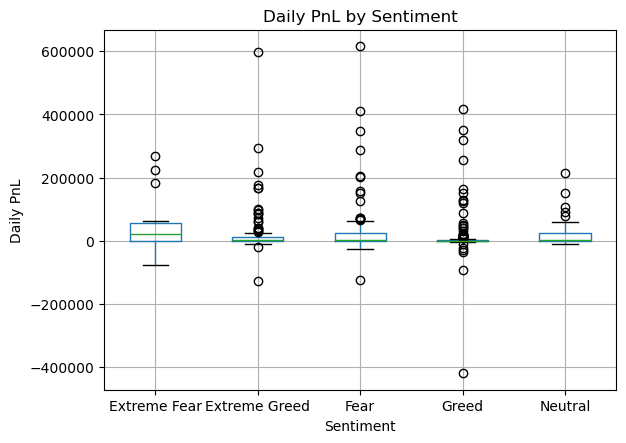

In [16]:
plt.figure()
data.boxplot(column="daily_pnl", by="classification")
plt.title("Daily PnL by Sentiment")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("Daily PnL")
plt.show()


<Figure size 640x480 with 0 Axes>

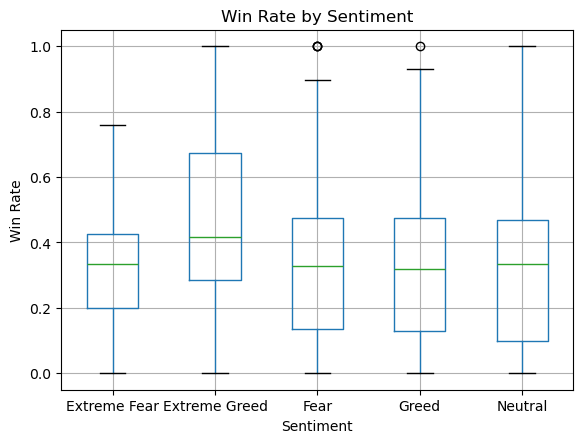

In [17]:
plt.figure()
data.boxplot(column="win_rate", by="classification")
plt.title("Win Rate by Sentiment")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("Win Rate")
plt.show()


In [18]:
behavior = data.groupby("classification").agg(
    avg_trades=("trades_per_day", "mean"),
    avg_trade_size=("avg_trade_size", "mean"),
    avg_leverage=("avg_leverage", "mean"),
    long_ratio=("long_ratio", "mean")
).sort_values("avg_trades", ascending=False)

behavior


,avg_trades,avg_trade_size,avg_leverage,long_ratio
classification,,,,
Extreme Fear,1528.571429,4091.804366,10481.212846,0.0
Fear,679.527473,6524.294937,49114.556748,0.0
Neutral,562.477612,7157.527121,80715.120368,0.0
Extreme Greed,350.807018,4410.524482,11700.023452,0.0
Greed,260.637306,6735.295813,6203.341662,0.0


<Figure size 640x480 with 0 Axes>

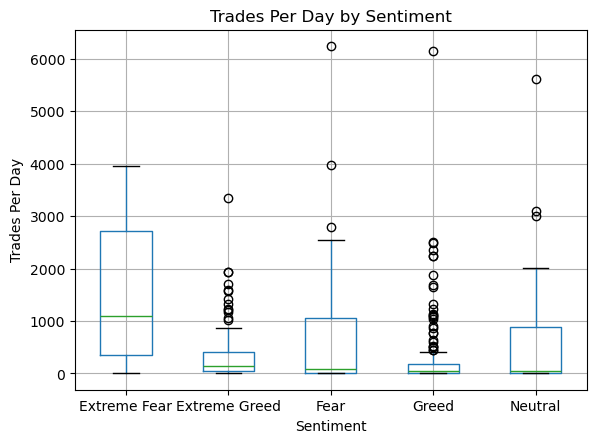

In [19]:
plt.figure()
data.boxplot(column="trades_per_day", by="classification")
plt.title("Trades Per Day by Sentiment")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("Trades Per Day")
plt.show()


<Figure size 640x480 with 0 Axes>

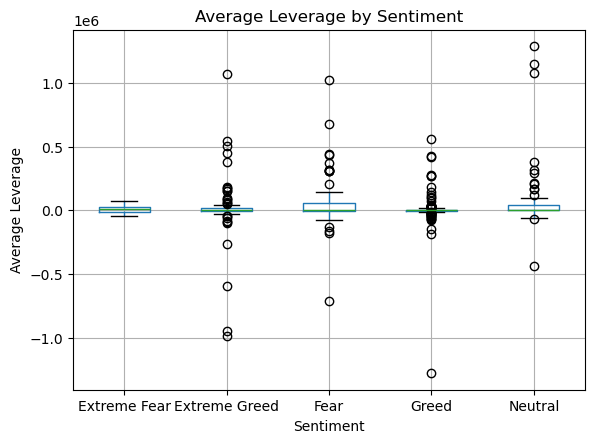

In [20]:
plt.figure()
data.boxplot(column="avg_leverage", by="classification")
plt.title("Average Leverage by Sentiment")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("Average Leverage")
plt.show()


In [21]:
# Calculate trader-level average leverage
trader_leverage = trades.groupby("Account")["Start Position"].mean()

# Median leverage threshold
median_leverage = trader_leverage.median()

# Map segment back to trades
trades["leverage_segment"] = trades["Account"].map(
    lambda x: "High Leverage" if trader_leverage[x] > median_leverage else "Low Leverage"
)

trades[["Account", "Start Position", "leverage_segment"]].head()


,Account,Start Position,leverage_segment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.000000,High Leverage
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,986.524596,High Leverage
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,1002.518996,High Leverage
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,1146.558564,High Leverage
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,1289.488521,High Leverage


In [22]:
seg1 = trades.groupby("leverage_segment")["Closed PnL"].mean()
seg1


leverage_segment
High Leverage    50.153193
Low Leverage     45.980561
Name: Closed PnL, dtype: float64

In [23]:
# Count trades per trader
trader_freq = trades.groupby("Account").size()

# Median threshold
median_freq = trader_freq.median()

# Assign segment
trades["frequency_segment"] = trades["Account"].map(
    lambda x: "Frequent" if trader_freq[x] > median_freq else "Infrequent"
)

trades[["Account", "frequency_segment"]].head()


,Account,frequency_segment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent


In [24]:
seg2 = trades.groupby("frequency_segment")["Closed PnL"].mean()
seg2


frequency_segment
Frequent      42.493421
Infrequent    96.943024
Name: Closed PnL, dtype: float64

In [25]:
# Trader-level win rate
trader_win_rate = trades.groupby("Account")["is_win"].mean()

# Threshold (60% win rate)
trades["consistency_segment"] = trades["Account"].map(
    lambda x: "Consistent" if trader_win_rate[x] > 0.6 else "Inconsistent"
)

trades[["Account", "consistency_segment"]].head()


,Account,consistency_segment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Inconsistent
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Inconsistent
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Inconsistent
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Inconsistent
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Inconsistent


In [26]:
seg3 = trades.groupby("consistency_segment")["Closed PnL"].mean()
seg3


consistency_segment
Consistent      38.319560
Inconsistent    49.261483
Name: Closed PnL, dtype: float64

In [27]:
# Sort by date
data = data.sort_values("date")

# Create next-day PnL
data["next_day_pnl"] = data["daily_pnl"].shift(-1)

# Create binary target
data["target"] = (data["next_day_pnl"] > 0).astype(int)

# Drop last row (NaN target)
data = data.dropna()

data[["date", "daily_pnl", "next_day_pnl", "target"]].head()


,date,daily_pnl,next_day_pnl,target
0,2023-05-01,0.000000,0.000000,0
1,2023-12-05,0.000000,-205.434737,0
2,2023-12-14,-205.434737,-24.632034,0
3,2023-12-15,-24.632034,0.000000,0
4,2023-12-16,0.000000,304.982785,1


In [28]:
from sklearn.model_selection import train_test_split

features = [
    "value",          # sentiment index value
    "win_rate",
    "trades_per_day",
    "avg_leverage",
    "long_ratio"
]

X = data[features]
y = data["target"]

# Train-test split (time-aware split)
split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (382, 5)
Test size: (96, 5)


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, predictions))
print("\nClassification Report:\n")
print(classification_report(y_test, predictions))


Accuracy: 0.8229166666666666

Classification Report:

              precision    recall  f1-score   support

           0       0.11      0.10      0.11        10
           1       0.90      0.91      0.90        86

    accuracy                           0.82        96
   macro avg       0.50      0.50      0.50        96
weighted avg       0.81      0.82      0.82        96



In [30]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

importance


value             0.295872
avg_leverage      0.258129
win_rate          0.234849
trades_per_day    0.211150
long_ratio        0.000000
dtype: float64

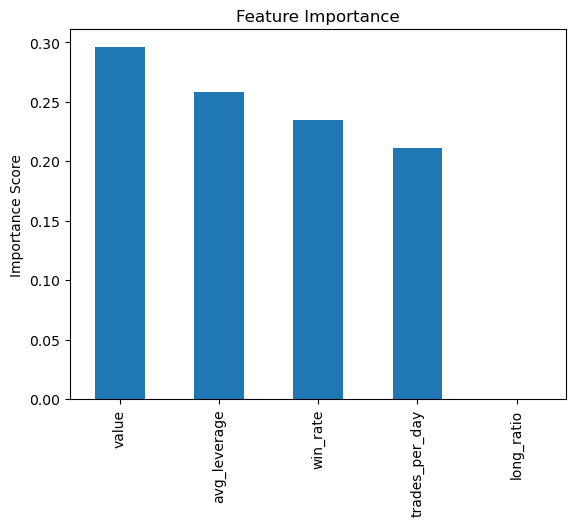

In [31]:
plt.figure()
importance.plot(kind="bar")
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()
